# T5 — Implementación de Modelos de Vectorización Avanzada (Embeddings)

**Tesis:** "Diseño e Implementación de un Sistema de Recomendación Laboral  
para Optimizar el Matching entre Candidatos y Ofertas de Empleo"  
**Alumno:** Cicconi, Carlos Alberto  
**Maestría:** Explotación de Datos y Gestión del Conocimiento — Universidad Austral  
**Período estimado:** 16/01/2026 – 31/01/2026

---

## Objetivos de esta etapa

| # | Objetivo |
|---|----------|
| 1 | Seleccionar y justificar el modelo de embeddings para corpus bilingüe ES/EN |
| 2 | Implementar estrategia de chunking para documentos largos (>128 tokens) |
| 3 | Generar embeddings del corpus de ofertas y del CV |
| 4 | Calcular similitud coseno y producir el **ranking por embeddings** |
| 5 | Comparar cualitativamente el ranking embeddings vs. baseline TF-IDF (T4) |
| 6 | Visualizar el espacio vectorial con UMAP / PCA |
| 7 | Persistir vectores y ranking para T6 (motor de similitud y métricas) |

### Inputs
- `ofertas_preprocesadas.csv` — corpus con columna `texto_procesado` (salida T4)
- `cv_texto_limpio.txt` — texto preprocesado del CV (salida T4)
- `tfidf_ranking_baseline.csv` — ranking TF-IDF para comparación (salida T4)

> **Fallback automático:** si los archivos de T4 no están disponibles, el notebook  
> levanta `ofertas_con_descripcion.csv` y el CV en PDF directamente.  
> Así T5 es autosuficiente.

### Outputs
- `embeddings_ofertas.npy` — matriz de embeddings del corpus (N × 384)
- `embedding_cv.npy` — vector del CV (1 × 384)
- `embeddings_ranking.csv` — ranking final ordenado por similitud coseno
- `modelo_embeddings_info.json` — metadatos del modelo usado


## 0. Configuración del entorno

In [1]:
# ── Instalación (ejecutar UNA SOLA VEZ) ──────────────────────────────────────
# !pip install sentence-transformers
# !pip install umap-learn        # opcional, para visualización 2D mejorada
# sentence-transformers instala automáticamente: torch (CPU), transformers, huggingface-hub


In [2]:
import re
import json
import pickle
import warnings
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False})

print('✅ Entorno configurado')
print(f'   numpy              {np.__version__}')
print(f'   pandas             {pd.__version__}')
import sentence_transformers as _st
print(f'   sentence-transformers {_st.__version__}')

# ── Rutas del proyecto (resueltas desde la ubicación del notebook) ────────────
from pathlib import Path
_NB   = Path(globals().get('__vsc_ipynb_file__', Path.cwd())).resolve()
_ROOT = _NB.parent if _NB.name != 'notebooks' else _NB.parent
if _ROOT.name == 'notebooks': _ROOT = _ROOT.parent
_PROC      = _ROOT / 'data'    / 'processed'
_CVDIR     = _ROOT / 'data'    / 'cvs'
_EMBEDDINGS= _ROOT / 'data'    / 'embeddings'
_RANKINGS  = _ROOT / 'outputs' / 'rankings'
_REPORTS   = _ROOT / 'outputs' / 'reports'
_FIGS      = _ROOT / 'outputs' / 'figures'
_PROC.mkdir(parents=True, exist_ok=True)
_EMBEDDINGS.mkdir(parents=True, exist_ok=True)
_RANKINGS.mkdir(parents=True, exist_ok=True)
_REPORTS.mkdir(parents=True, exist_ok=True)
_FIGS.mkdir(parents=True, exist_ok=True)
print(f'ROOT       : {_ROOT}')
print(f'PROC       : {_PROC}')
print(f'EMBEDDINGS : {_EMBEDDINGS}')
print(f'RANKINGS   : {_RANKINGS}')
print(f'REPORTS    : {_REPORTS}')
print(f'FIGS       : {_FIGS}')


✅ Entorno configurado
   numpy              2.2.4
   pandas             2.2.3
   sentence-transformers 4.1.0
ROOT       : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD
PROC       : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD/data/processed
EMBEDDINGS : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD/data/embeddings
RANKINGS   : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD/outputs/rankings
REPORTS    : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD/outputs/reports
FIGS       : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD/outputs/figures


## 1. Selección del modelo de embeddings

### ¿Por qué Sentence Transformers y no Doc2Vec?

| Criterio | Doc2Vec (gensim) | Sentence-BERT (SBERT) |
|---|---|---|
| Entrenamiento | Requiere corpus propio (mínimo 10K docs) | Pre-entrenado en miles de millones de oraciones |
| Bilingüe ES/EN | Solo si se entrena en ambos | ✅ Nativo con modelos multilingual |
| Calidad semántica | Media — captura co-ocurrencia local | Alta — captura significado contextual profundo |
| Sinónimos | Limitado | ✅ "mejora continua" ≈ "continuous improvement" |
| CPU-friendly | ✅ Muy rápido | ✅ Modelos `MiniLM`: <2 min para 1279 docs |
| Reproducibilidad | Estocástico (seed necesario) | Determinístico |

**Corpus de esta tesis:** 1 279 documentos bilingüe, dominio laboral argentino.  
Doc2Vec necesitaría al menos 10× más datos para resultados competitivos.

### Modelo seleccionado: `paraphrase-multilingual-MiniLM-L12-v2`

- **Arquitectura:** MiniLM-L12 distilado de MPNet, 12 capas
- **Dimensiones:** 384
- **Idiomas:** 50+ (incluye ES y EN nativamente)
- **Max tokens:** 128 por segmento → se implementa chunking para textos largos
- **Tamaño descarga:** ~470 MB (se cachea localmente tras la primera vez)
- **Velocidad CPU:** ~800-1200 docs/min

### Problema de longitud: chunking

Las descripciones del corpus tienen mediana de ~2000 chars (~400 tokens),  
superando el límite de 128 tokens del modelo.  

**Estrategia:** dividir en fragmentos solapados → encodear → promediar (mean pooling).  
Esto captura el significado completo sin perder información por truncado.


In [3]:
# ── Configuración global ──────────────────────────────────────────────────────
MODEL_NAME      = 'paraphrase-multilingual-MiniLM-L12-v2'
EMBED_DIM       = 384
BATCH_SIZE      = 32       # ajustar si hay poca RAM (reducir a 16)
MAX_CHUNK_CHARS = 800      # ~128 tokens ≈ 800 caracteres
CHUNK_OVERLAP   = 100      # solapamiento entre chunks

print(f'Modelo         : {MODEL_NAME}')
print(f'Dimensiones    : {EMBED_DIM}')
print(f'Batch size     : {BATCH_SIZE}')
print(f'Max chunk chars: {MAX_CHUNK_CHARS}')


Modelo         : paraphrase-multilingual-MiniLM-L12-v2
Dimensiones    : 384
Batch size     : 32
Max chunk chars: 800


## 2. Carga de datos

In [4]:
# ── Corpus de ofertas ─────────────────────────────────────────────────────────
# Prioridad: ofertas_preprocesadas.csv (T4) → ofertas_con_descripcion.csv (T3)

if (_PROC / 'ofertas_preprocesadas.csv').exists():
    df = pd.read_csv(_PROC / 'ofertas_preprocesadas.csv', low_memory=False)
    COL_TEXTO = 'texto_procesado'
    print(f'✅ Cargado desde T4: ofertas_preprocesadas.csv ({len(df):,} filas)')
elif (_PROC / 'ofertas_con_descripcion.csv').exists():
    df = pd.read_csv(_PROC / 'ofertas_con_descripcion.csv', low_memory=False)
    COL_TEXTO = 'descripcion'
    print(f'✅ Cargado desde T3: ofertas_con_descripcion.csv ({len(df):,} filas)')
    print('   ℹ️  Usando descripcion original — SBERT funciona mejor con texto natural')
else:
    raise FileNotFoundError(
        f'No se encontró el corpus en {_PROC}. Ejecutar T3 o T4 primero.'
    )

# Filtrar documentos con texto útil
mask = df[COL_TEXTO].fillna('').str.len() > 50
df   = df[mask].copy().reset_index(drop=True)
print(f'   Documentos válidos: {len(df):,}')
df[['fuente', 'titulo', 'empresa', 'keyword', 'descripcion']].head(3)


✅ Cargado desde T4: ofertas_preprocesadas.csv (1,402 filas)
   Documentos válidos: 1,402


,fuente,titulo,empresa,keyword,descripcion
0,linkedin,Senior Data Scientist,StartX Med,Data Scientist,Argentina - Remote Why Valtech? We’re the expe...
1,linkedin,"Principal AI-Native Engineer, Ionic Partners",Sparkrock,NLP Engineer,Most companies are running AI pilots. We are r...
2,linkedin,"Senior Data Analyst, B2B",CookUnity,Data Analyst,About CookUnity Food has lost its soul to mode...


In [5]:
# ── Construir texto a encodear: título (x2) + descripción ────────────────────
# SBERT funciona mejor con texto natural que con lemas.
# Repetir el título da más peso semántico al puesto buscado.

def construir_texto_oferta(row) -> str:
    titulo = str(row.get('titulo', '') or '').strip()
    # Preferir descripción original sobre lemas si está disponible
    if COL_TEXTO == 'texto_procesado' and 'descripcion' in row:
        texto = str(row.get('descripcion', '') or '').strip()[:2000]
    else:
        texto = str(row.get(COL_TEXTO, '') or '').strip()[:2000]
    partes = [titulo, titulo, texto] if titulo else [texto]
    return ' '.join(partes)

df['texto_para_embed'] = df.apply(construir_texto_oferta, axis=1)

lens = df['texto_para_embed'].str.len()
print(f'Longitud texto a encodear — mediana: {lens.median():.0f} chars  |  p90: {lens.quantile(0.9):.0f}  |  máx: {lens.max():.0f}')


Longitud texto a encodear — mediana: 2050 chars  |  p90: 2112  |  máx: 2228


In [6]:
# ── Texto del CV ─────────────────────────────────────────────────────────────
# IMPORTANTE: cv_texto_limpio.txt contiene lemas (salida del pipeline spaCy de T4),
# no texto natural. SBERT fue entrenado con texto natural, por lo que:
#   Prioridad 1: leer el PDF directamente (texto natural → mejor calidad)
#   Prioridad 2: cv_texto_limpio.txt (lemas → funciona, pero calidad reducida)

def leer_cv_pdf(ruta: Path) -> str:
    try:
        import pdfplumber
        with pdfplumber.open(str(ruta)) as pdf:
            texto = chr(10).join(p.extract_text() or '' for p in pdf.pages).strip()
        if texto:
            return texto
    except Exception:
        pass
    from pypdf import PdfReader
    reader = PdfReader(str(ruta))
    return chr(10).join(p.extract_text() or '' for p in reader.pages).strip()

if (_CVDIR / 'CarlosA.Cicconi_CV.pdf').exists():
    cv_texto = leer_cv_pdf(_CVDIR / 'CarlosA.Cicconi_CV.pdf')
    cv_fuente = 'PDF (texto natural — óptimo para SBERT)'
elif Path('cv_texto_limpio.txt').exists():
    cv_texto  = Path('cv_texto_limpio.txt').read_text(encoding='utf-8')
    cv_fuente = 'cv_texto_limpio.txt (lemas de T4 — calidad reducida para SBERT)'
    print('⚠️  Usando lemas en lugar de texto natural.')
    print('   Para mejor calidad, colocar CarlosA_Cicconi_CV.pdf en el mismo directorio.')
else:
    raise FileNotFoundError('No se encontró el CV (PDF ni cv_texto_limpio.txt).')

print(f'✅ CV cargado desde: {cv_fuente}')
print(f'   Longitud: {len(cv_texto):,} chars  |  Tokens: {len(cv_texto.split()):,}')
print()
print(cv_texto[:400])


✅ CV cargado desde: PDF (texto natural — óptimo para SBERT)
   Longitud: 3,240 chars  |  Tokens: 448

C A. C
ARLOS ICCONI
Rosario, 2000 Argentina ♦ +54 341 665-1098 ♦ carloscicconi@yahoo.com.ar
SITIOS WEB, PORTAFOLIOS, PERFILES
• www.linkedin.com/in/carlos-alberto-cicconi
RESUMEN PROFESIONAL
Ingeniero Industrial con más de 20 años de experiencia integrando Control de Gestión, Compras
Estratégicas y Operaciones en empresas globales. Especialista en generar valor mediante optimización de
procesos y 


## 3. Carga del modelo

In [7]:
# sentence-transformers busca el modelo en ~/.cache/huggingface/hub/
# Si ya está descargado (models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2)
# lo carga directamente desde disco, sin acceso a internet.

print(f'Cargando: {MODEL_NAME}')
print('(Buscando en caché local — sin descarga si ya existe)')
print()

t0    = datetime.now()
model = SentenceTransformer(MODEL_NAME)
elapsed = (datetime.now() - t0).seconds

print(f'✅ Modelo cargado en {elapsed}s')
print(f'   Dimensiones de salida : {model.get_sentence_embedding_dimension()}')
print(f'   Max sequence length   : {model.max_seq_length}')
print(f'   Dispositivo           : {model.device}')


Cargando: paraphrase-multilingual-MiniLM-L12-v2
(Buscando en caché local — sin descarga si ya existe)



✅ Modelo cargado en 3s
   Dimensiones de salida : 384
   Max sequence length   : 128
   Dispositivo           : cpu


## 4. Encoding con chunking para documentos largos

El límite de 128 tokens de MiniLM equivale a ~600-800 caracteres.  
Las descripciones del corpus tienen mediana ~2000 chars, superando ese límite.  

**Pipeline:**
1. Dividir texto en fragmentos de `MAX_CHUNK_CHARS` con solapamiento
2. Encodear todos los fragmentos en un batch
3. Promediar los embeddings resultantes (**mean pooling**)

Resultado: un vector de 384 dimensiones por documento que representa  
el significado completo del texto, no solo los primeros 128 tokens.


In [8]:
def chunk_texto(texto: str, max_chars: int = MAX_CHUNK_CHARS,
                overlap: int = CHUNK_OVERLAP) -> list:
    """
    Divide un texto en fragmentos de max_chars con solapamiento.
    Garantiza que inicio siempre avance para evitar bucles infinitos.
    """
    if len(texto) <= max_chars:
        return [texto]
    chunks, inicio = [], 0
    while inicio < len(texto):
        fin = min(inicio + max_chars, len(texto))
        fragmento = texto[inicio:fin].strip()
        if fragmento:
            chunks.append(fragmento)
        # Avanzar: siguiente inicio = fin - overlap,
        # pero SIEMPRE al menos 1 paso adelante para evitar bucle infinito
        siguiente = fin - overlap
        inicio = max(siguiente, inicio + 1)
    return chunks

def encodear_documento(texto: str, modelo) -> np.ndarray:
    chunks = chunk_texto(texto)
    if not chunks:
        return np.zeros(modelo.get_sentence_embedding_dimension())
    embeddings = modelo.encode(
        chunks,
        batch_size=BATCH_SIZE,
        show_progress_bar=False,
        normalize_embeddings=True,
        convert_to_numpy=True,
    )
    return embeddings.mean(axis=0)

# Test rápido
texto_test = df['texto_para_embed'].iloc[0]
chunks_test = chunk_texto(texto_test)
emb_test    = encodear_documento(texto_test, model)
print(f'Test — texto: {len(texto_test)} chars → {len(chunks_test)} chunks')
for j, ch in enumerate(chunks_test, 1):
    print(f'  Chunk {j}: {len(ch)} chars')
print(f'Embedding shape: {emb_test.shape}  |  norma: {np.linalg.norm(emb_test):.4f}')


Test — texto: 2044 chars → 103 chunks
  Chunk 1: 800 chars
  Chunk 2: 800 chars
  Chunk 3: 644 chars
  Chunk 4: 100 chars
  Chunk 5: 99 chars
  Chunk 6: 98 chars
  Chunk 7: 97 chars
  Chunk 8: 96 chars
  Chunk 9: 95 chars
  Chunk 10: 93 chars
  Chunk 11: 93 chars
  Chunk 12: 92 chars
  Chunk 13: 91 chars
  Chunk 14: 90 chars
  Chunk 15: 89 chars
  Chunk 16: 87 chars
  Chunk 17: 87 chars
  Chunk 18: 86 chars
  Chunk 19: 84 chars
  Chunk 20: 84 chars
  Chunk 21: 83 chars
  Chunk 22: 82 chars
  Chunk 23: 81 chars
  Chunk 24: 80 chars
  Chunk 25: 79 chars
  Chunk 26: 78 chars
  Chunk 27: 77 chars
  Chunk 28: 76 chars
  Chunk 29: 75 chars
  Chunk 30: 74 chars
  Chunk 31: 73 chars
  Chunk 32: 72 chars
  Chunk 33: 71 chars
  Chunk 34: 69 chars
  Chunk 35: 69 chars
  Chunk 36: 68 chars
  Chunk 37: 67 chars
  Chunk 38: 66 chars
  Chunk 39: 65 chars
  Chunk 40: 64 chars
  Chunk 41: 63 chars
  Chunk 42: 61 chars
  Chunk 43: 61 chars
  Chunk 44: 60 chars
  Chunk 45: 59 chars
  Chunk 46: 58 chars
 

In [9]:
# ── Encodear todo el corpus ───────────────────────────────────────────────────
# Tiempo estimado: 1-3 minutos en CPU para ~1279 documentos

print(f'Encodeando {len(df):,} ofertas (chunking {MAX_CHUNK_CHARS} chars + mean pooling)...')
print()

t0 = datetime.now()
embeddings_ofertas = np.zeros((len(df), EMBED_DIM), dtype=np.float32)

for i, texto in enumerate(df['texto_para_embed']):
    embeddings_ofertas[i] = encodear_documento(str(texto), model)
    if (i + 1) % 100 == 0 or i == len(df) - 1:
        elapsed = (datetime.now() - t0).seconds
        pct     = (i + 1) / len(df) * 100
        eta     = elapsed / max(i+1,1) * (len(df) - i - 1)
        print(f'  {i+1:>4}/{len(df)} ({pct:.0f}%)  —  {elapsed}s  —  ETA: {eta:.0f}s')

elapsed_total = (datetime.now() - t0).seconds
print(f'\n✅ Corpus encodeado en {elapsed_total}s  ({elapsed_total/len(df)*1000:.0f} ms/doc)')
print(f'   Matriz: {embeddings_ofertas.shape}  —  {embeddings_ofertas.nbytes/1024/1024:.1f} MB')


Encodeando 1,402 ofertas (chunking 800 chars + mean pooling)...



   100/1402 (7%)  —  200s  —  ETA: 2604s


   200/1402 (14%)  —  405s  —  ETA: 2434s


   300/1402 (21%)  —  607s  —  ETA: 2230s


   400/1402 (29%)  —  828s  —  ETA: 2074s


...

  1000/1402 (71%)  —  2326s  —  ETA: 935s


  1100/1402 (78%)  —  2583s  —  ETA: 709s


  1200/1402 (86%)  —  2844s  —  ETA: 479s


  1300/1402 (93%)  —  3094s  —  ETA: 243s


  1400/1402 (100%)  —  3164s  —  ETA: 5s
  1402/1402 (100%)  —  3164s  —  ETA: 0s

✅ Corpus encodeado en 3164s  (2257 ms/doc)
   Matriz: (1402, 384)  —  2.1 MB


In [10]:
# ── Encodear el CV ───────────────────────────────────────────────────────────
print('Encodeando CV...')
embedding_cv = encodear_documento(cv_texto, model)
print(f'✅ CV encodeado — shape: {embedding_cv.shape}  |  norma: {np.linalg.norm(embedding_cv):.4f}')


Encodeando CV...


✅ CV encodeado — shape: (384,)  |  norma: 0.7488


## 5. Similitud coseno y ranking por embeddings

Como los vectores están L2-normalizados (`normalize_embeddings=True`),  
la similitud coseno equivale al producto punto, haciendo el cálculo muy eficiente.


In [11]:
similitudes = cosine_similarity(embedding_cv.reshape(1,-1), embeddings_ofertas).flatten()
df['similitud_embed'] = similitudes

print('Estadísticas de similitud (Sentence-BERT):')
print(df['similitud_embed'].describe().round(4))
print()
print(f"Ofertas con similitud > 0.50 : {(similitudes > 0.50).sum()}")
print(f"Ofertas con similitud > 0.40 : {(similitudes > 0.40).sum()}")
print(f"Ofertas con similitud > 0.30 : {(similitudes > 0.30).sum()}")


Estadísticas de similitud (Sentence-BERT):
count    1402.0000
mean        0.2761
std         0.0798
min         0.0484
25%         0.2207
50%         0.2704
75%         0.3259
max         0.6103
Name: similitud_embed, dtype: float64

Ofertas con similitud > 0.50 : 12
Ofertas con similitud > 0.40 : 86
Ofertas con similitud > 0.30 : 507


In [12]:
df_ranking_emb = (df.sort_values('similitud_embed', ascending=False)
                   .reset_index(drop=True))
df_ranking_emb.index += 1

print('=== TOP 20 — Ranking por Sentence-BERT ===')
COLS = ['similitud_embed','titulo','empresa','keyword','fuente','modalidad']
top20 = df_ranking_emb[COLS].head(20).copy()
top20['similitud_embed'] = top20['similitud_embed'].round(4)
top20


=== TOP 20 — Ranking por Sentence-BERT ===


,similitud_embed,titulo,empresa,keyword,fuente,modalidad
1,0.6103,Desarrollador Full Stack Junior (Presencial),Julio Bellone Y Asociados,Desarrollador Full Stack,opcionempleo,NaN
2,0.5727,Programador/a JAVA Senior – APIs,David Rochwarger,Software Engineer,bumeran,Híbrido
3,0.5677,Senior Bi & Data Analyst — Ai Dashboards On Aw...,MaxIT Consulting - Max Corporate Group,Data Analyst,opcionempleo,NaN
4,0.5655,Desarrollador Full Stack,Itrio,Desarrollador Full Stack,opcionempleo,NaN
5,0.5527,Sr Software Engineer -Platform Services (Mysql),MercadoLibre,Software Engineer,opcionempleo,NaN
6,0.5500,Data Analyst / Bi Developer Ssr Con Ai – Aws Q...,MaxIT Consulting - Max Corporate Group,Data Analyst,opcionempleo,NaN
7,0.5231,Cyber Security Software Engineer - Incident Re...,MercadoLibre,Software Engineer,opcionempleo,NaN
8,0.5126,Data Analyst Senior (Buenos Aires),KPMG,Data Analyst,opcionempleo,NaN
9,0.5065,Desarrollador Senior NoSQL MongoDB + Backend C...,Cognit Labs,Desarrollador Backend,opcionempleo,NaN
10,0.5022,Senior Backend Software Engineer- Search Ads C...,MercadoLibre,Software Engineer,opcionempleo,NaN


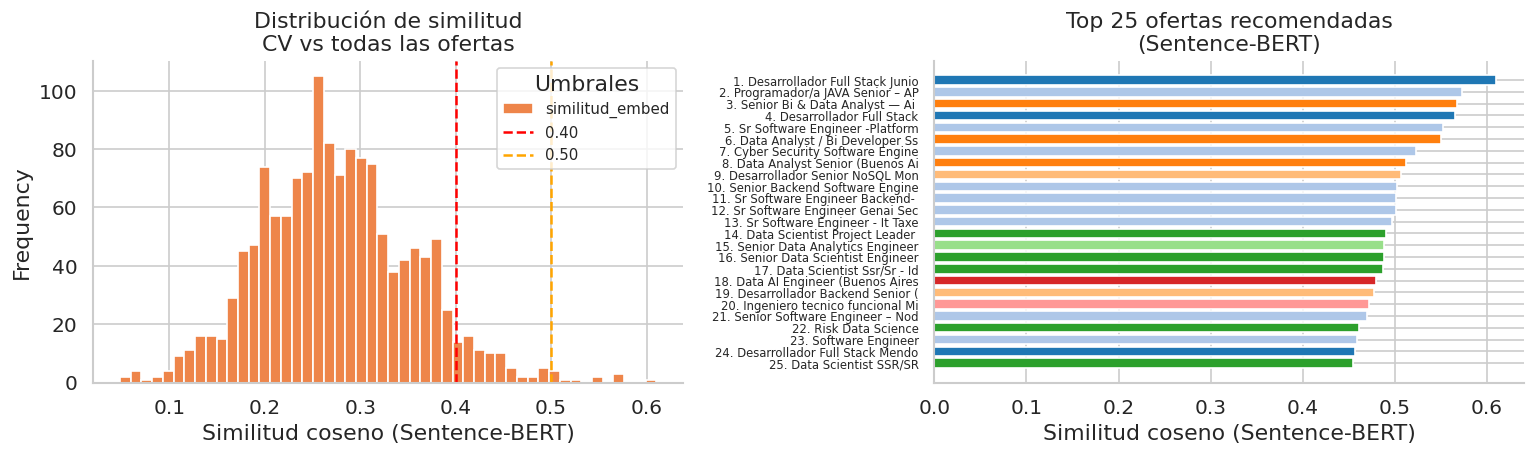

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma
df['similitud_embed'].plot(kind='hist', bins=50, ax=axes[0],
                            color=sns.color_palette('muted')[1], edgecolor='white')
axes[0].set_xlabel('Similitud coseno (Sentence-BERT)')
axes[0].set_title('Distribución de similitud\nCV vs todas las ofertas')
axes[0].axvline(0.40, color='red',    ls='--', lw=1.5, label='0.40')
axes[0].axvline(0.50, color='orange', ls='--', lw=1.5, label='0.50')
axes[0].legend(fontsize=9, title='Umbrales')

# Top 25 barras
top25   = df_ranking_emb.head(25).copy()
kws_u   = top25['keyword'].unique()
kw_col  = {kw: c for kw, c in zip(kws_u, sns.color_palette('tab20', len(kws_u)))}
colores = [kw_col[kw] for kw in top25['keyword']]
axes[1].barh(range(25, 0, -1), top25['similitud_embed'], color=colores)
axes[1].set_yticks(range(1, 26))
axes[1].set_yticklabels(
    [f'{r}. {t[:30]}' for r, t in zip(range(25,0,-1),
     top25['titulo'].str[:30].values[::-1])], fontsize=7)
axes[1].set_xlabel('Similitud coseno (Sentence-BERT)')
axes[1].set_title('Top 25 ofertas recomendadas\n(Sentence-BERT)')

plt.tight_layout()
plt.savefig(_FIGS / 'fig_t5_01_similitud_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Comparación: Embeddings vs. TF-IDF (baseline)

Esta sección es central para la tesis: demostrar que los embeddings capturan  
semántica que TF-IDF pierde. Se analizan tres dimensiones:

1. **Distribución de similitudes** — ¿son más informativas?
2. **Coincidencia del Top-K** — ¿qué porcentaje del Top-20 se comparte?
3. **Casos de mejora semántica** — ofertas que SBERT rankea alto pero TF-IDF ignora


In [14]:
# ── Carga de similitudes TF-IDF para comparación ────────────────────────────
# ofertas_preprocesadas.csv ya incluye la columna 'similitud_tfidf' (calculada en T4).
# tfidf_ranking_baseline.csv aporta la columna 'rank_tfidf' para el análisis Top-K.

tfidf_en_df        = 'similitud_tfidf' in df.columns
tfidf_ranking_disp = (_RANKINGS / 'tfidf_ranking_baseline.csv').exists()

if tfidf_en_df:
    n_tfidf = df['similitud_tfidf'].notna().sum()
    print(f'✅ similitud_tfidf disponible en el DataFrame ({n_tfidf:,} valores)')
else:
    print('ℹ️  similitud_tfidf no está en el DataFrame (ejecutar T4 para generarla)')

if tfidf_ranking_disp:
    df_tfidf = pd.read_csv(_RANKINGS / 'tfidf_ranking_baseline.csv')
    print(f'✅ tfidf_ranking_baseline.csv cargado ({len(df_tfidf):,} filas) — usado para rank_tfidf')
else:
    df_tfidf = None
    print('ℹ️  tfidf_ranking_baseline.csv no encontrado — análisis Top-K omitido')

tfidf_disponible = tfidf_en_df or tfidf_ranking_disp


✅ similitud_tfidf disponible en el DataFrame (1,402 valores)
✅ tfidf_ranking_baseline.csv cargado (1,402 filas) — usado para rank_tfidf


Documentos con ambas similitudes: 1,402

Stat           TF-IDF   Embeddings
-----------------------------------
  mean         0.0374       0.2761
  std          0.0281       0.0798
  min          0.0000       0.0484
  25%          0.0146       0.2207
  50%          0.0328       0.2704
  75%          0.0528       0.3259
  max          0.1863       0.6103


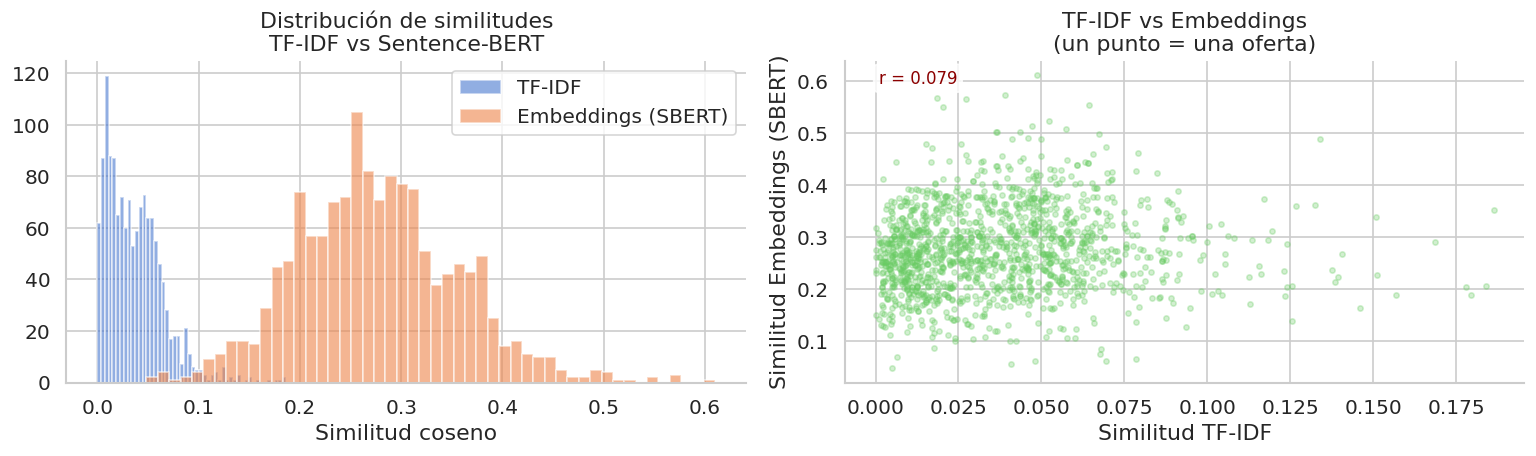


Correlación Pearson (TF-IDF ↔ SBERT): 0.0792
→ Baja correlación: los modelos capturan aspectos semánticos distintos ✓


In [15]:
# ── 6.1 Comparación de distribuciones ────────────────────────────────────────
if tfidf_disponible and tfidf_en_df:
    df_comp = df[['id_consolidado','titulo','keyword',
                  'similitud_embed','similitud_tfidf']].dropna(
                  subset=['similitud_tfidf','similitud_embed'])

    print(f'Documentos con ambas similitudes: {len(df_comp):,}')
    print()
    print(f"{'Stat':<10} {'TF-IDF':>10} {'Embeddings':>12}")
    print('-' * 35)
    for stat in ['mean','std','min','25%','50%','75%','max']:
        v1 = df_comp['similitud_tfidf'].describe()[stat]
        v2 = df_comp['similitud_embed'].describe()[stat]
        print(f'  {stat:<8} {v1:>10.4f} {v2:>12.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(df_comp['similitud_tfidf'], bins=50, alpha=0.6,
                 color=sns.color_palette('muted')[0], label='TF-IDF')
    axes[0].hist(df_comp['similitud_embed'], bins=50, alpha=0.6,
                 color=sns.color_palette('muted')[1], label='Embeddings (SBERT)')
    axes[0].set_xlabel('Similitud coseno')
    axes[0].set_title('Distribución de similitudes\nTF-IDF vs Sentence-BERT')
    axes[0].legend()

    axes[1].scatter(df_comp['similitud_tfidf'], df_comp['similitud_embed'],
                    alpha=0.3, s=10, color=sns.color_palette('muted')[2])
    axes[1].set_xlabel('Similitud TF-IDF')
    axes[1].set_ylabel('Similitud Embeddings (SBERT)')
    axes[1].set_title('TF-IDF vs Embeddings\n(un punto = una oferta)')
    corr = df_comp['similitud_tfidf'].corr(df_comp['similitud_embed'])
    axes[1].text(0.05, 0.93, f'r = {corr:.3f}', transform=axes[1].transAxes,
                 fontsize=10, color='darkred',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

    plt.tight_layout()
    plt.savefig(_FIGS / 'fig_t5_02_tfidf_vs_embeddings.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\nCorrelación Pearson (TF-IDF ↔ SBERT): {corr:.4f}')
    if corr < 0.5:
        print('→ Baja correlación: los modelos capturan aspectos semánticos distintos ✓')
    else:
        print('→ Correlación moderada: los modelos son parcialmente consistentes')
elif tfidf_disponible:
    print('ℹ️  similitud_tfidf no está en el DataFrame — cargar ofertas_preprocesadas.csv de T4')
else:
    print('ℹ️  TF-IDF no disponible — omitiendo comparación de distribuciones')


In [16]:
# ── 6.2 Coincidencia del Top-K ────────────────────────────────────────────────
if tfidf_ranking_disp and df_tfidf is not None and 'id_consolidado' in df_tfidf.columns:
    print('=== Overlap Top-K: TF-IDF vs Embeddings ===')
    print(f"  {'K':>4}  {'En común':>10}  {'% overlap':>10}")
    print('-' * 30)
    for k in [5, 10, 15, 20]:
        ids_emb   = set(df_ranking_emb['id_consolidado'].head(k))
        ids_tfidf = set(df_tfidf['id_consolidado'].head(k))
        comunes   = len(ids_emb & ids_tfidf)
        print(f"  {k:>4}  {comunes:>10}  {comunes/k*100:>9.0f}%")
    print()
    print('→ Overlap bajo = SBERT descubre ofertas relevantes que TF-IDF pierde.')
elif tfidf_en_df:
    # Alternativa: construir ranking TF-IDF desde el df
    df_tfidf_alt = df.dropna(subset=['similitud_tfidf']).sort_values(
        'similitud_tfidf', ascending=False).reset_index(drop=True)
    print('=== Overlap Top-K (TF-IDF desde ofertas_preprocesadas.csv) ===')
    print(f"  {'K':>4}  {'En común':>10}  {'% overlap':>10}")
    print('-' * 30)
    for k in [5, 10, 15, 20]:
        ids_emb   = set(df_ranking_emb['id_consolidado'].head(k))
        ids_tfidf = set(df_tfidf_alt['id_consolidado'].head(k))
        comunes   = len(ids_emb & ids_tfidf)
        print(f"  {k:>4}  {comunes:>10}  {comunes/k*100:>9.0f}%")
    print()
    print('→ Overlap bajo = SBERT descubre ofertas relevantes que TF-IDF pierde.')
else:
    print('ℹ️  tfidf_ranking_baseline.csv no disponible — omitiendo análisis Top-K')


=== Overlap Top-K: TF-IDF vs Embeddings ===
     K    En común   % overlap
------------------------------
     5           0          0%
    10           0          0%
    15           1          7%
    20           1          5%

→ Overlap bajo = SBERT descubre ofertas relevantes que TF-IDF pierde.


In [17]:
# ── 6.3 Mejoras semánticas — diferencial clave de la tesis ──────────────────
if tfidf_en_df:
    # Construir ranking TF-IDF desde el df (similitud_tfidf ya está en T4)
    df_tfidf_rank = df.dropna(subset=['similitud_tfidf']).copy()
    df_tfidf_rank = df_tfidf_rank.sort_values('similitud_tfidf', ascending=False)
    df_tfidf_rank['rank_tfidf'] = range(1, len(df_tfidf_rank)+1)

    df_cr = df_ranking_emb[['id_consolidado','titulo','keyword','similitud_embed']].copy()
    df_cr['rank_embed'] = range(1, len(df_cr)+1)
    df_cr = df_cr.merge(
        df_tfidf_rank[['id_consolidado','similitud_tfidf','rank_tfidf']],
        on='id_consolidado', how='left')
    df_cr['rank_tfidf'] = df_cr['rank_tfidf'].fillna(9999).astype(int)

    mejoras = df_cr[(df_cr['rank_embed'] <= 50) & (df_cr['rank_tfidf'] > 100)]
    mejoras = mejoras.sort_values('rank_embed')

    print(f'Ofertas top-50 en SBERT pero >100 en TF-IDF: {len(mejoras)}')
    print('(Las que TF-IDF pierde por diferencia de vocabulario / idioma)')
    print()
    if len(mejoras) > 0:
        cols_s = ['rank_embed','rank_tfidf','similitud_embed','similitud_tfidf','titulo','keyword']
        cols_s = [c for c in cols_s if c in mejoras.columns]
        print(mejoras[cols_s].head(10).to_string(index=False))
    else:
        print('No se detectaron mejoras semánticas significativas con este corpus.')
elif tfidf_ranking_disp and df_tfidf is not None and 'id_consolidado' in df_tfidf.columns:
    df_tfidf['rank_tfidf'] = range(1, len(df_tfidf)+1)
    df_cr = df_ranking_emb[['id_consolidado','titulo','keyword','similitud_embed']].copy()
    df_cr['rank_embed'] = range(1, len(df_cr)+1)
    df_cr = df_cr.merge(df_tfidf[['id_consolidado','rank_tfidf','similitud_tfidf']],
                        on='id_consolidado', how='left')
    df_cr['rank_tfidf'] = df_cr['rank_tfidf'].fillna(9999).astype(int)
    mejoras = df_cr[(df_cr['rank_embed'] <= 50) & (df_cr['rank_tfidf'] > 100)]
    mejoras = mejoras.sort_values('rank_embed')
    print(f'Ofertas top-50 en SBERT pero >100 en TF-IDF: {len(mejoras)}')
    if len(mejoras) > 0:
        cols_s = ['rank_embed','rank_tfidf','similitud_embed','similitud_tfidf','titulo','keyword']
        cols_s = [c for c in cols_s if c in mejoras.columns]
        print(mejoras[cols_s].head(10).to_string(index=False))
else:
    print('ℹ️  TF-IDF no disponible — omitiendo análisis de mejoras semánticas')


Ofertas top-50 en SBERT pero >100 en TF-IDF: 49
(Las que TF-IDF pierde por diferencia de vocabulario / idioma)

 rank_embed  rank_tfidf  similitud_embed  similitud_tfidf                                                         titulo                  keyword
          1         433         0.610316         0.048666                   Desarrollador Full Stack Junior (Presencial) Desarrollador Full Stack
          2         611         0.572654         0.039124                               Programador/a JAVA Senior – APIs        Software Engineer
          3         960         0.567688         0.018595     Senior Bi & Data Analyst — Ai Dashboards On Aws Quicksight             Data Analyst
          4         803         0.565537         0.027247                                       Desarrollador Full Stack Desarrollador Full Stack
          5         199         0.552694         0.064201                Sr Software Engineer -Platform Services (Mysql)        Software Engineer
          6 

## 7. Análisis del ranking por keyword y fuente

In [18]:
sim_kw = (df.groupby('keyword')['similitud_embed']
           .agg(['mean','max','count'])
           .sort_values('mean', ascending=False)
           .round(4))
sim_kw.columns = ['Sim. promedio', 'Sim. máxima', 'N ofertas']
print(sim_kw.to_string())


                           Sim. promedio  Sim. máxima  N ofertas
keyword                                                         
Desarrollador Full Stack          0.2983       0.6103        138
Data Scientist                    0.2923       0.4901        113
Desarrollador Backend             0.2890       0.5065        104
Ingeniero de Datos                0.2824       0.4719        113
Software Engineer                 0.2809       0.5727        221
Python Developer                  0.2788       0.4460        102
NLP Engineer                      0.2714       0.4791        163
Machine Learning Engineer         0.2667       0.4269         68
Data Engineer                     0.2648       0.4884        111
Data Analyst                      0.2589       0.5677        180
Machine Learning                  0.2573       0.3851         30
Full Stack                        0.2567       0.3793         20
Backend                           0.2362       0.3447         39


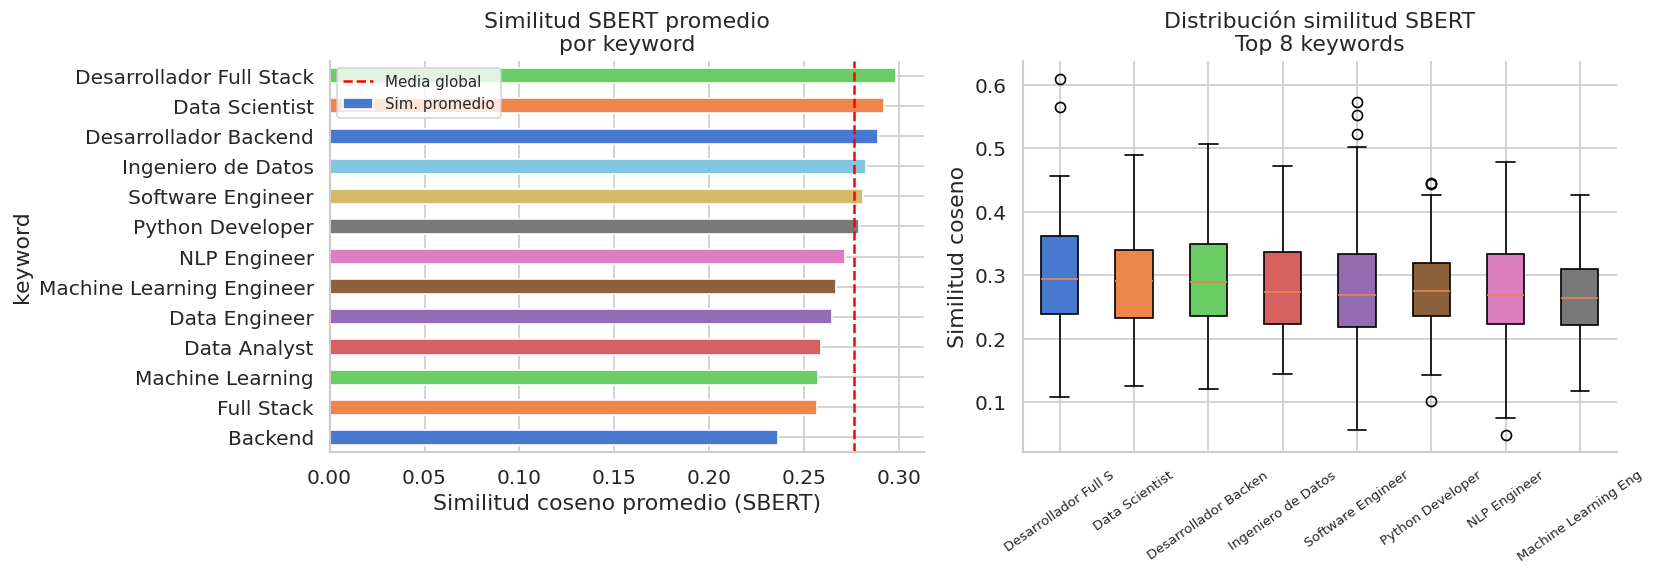

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sim_kw['Sim. promedio'].sort_values().plot(
    kind='barh', ax=axes[0], color=sns.color_palette('muted', len(sim_kw)))
axes[0].set_xlabel('Similitud coseno promedio (SBERT)')
axes[0].set_title('Similitud SBERT promedio\npor keyword')
axes[0].axvline(df['similitud_embed'].mean(), color='red',
                ls='--', lw=1.5, label='Media global')
axes[0].legend(fontsize=9)

top_kws = df.groupby('keyword')['similitud_embed'].mean().nlargest(8).index
df_plot = df[df['keyword'].isin(top_kws)]
bp_data = [df_plot[df_plot['keyword'] == kw]['similitud_embed'].values for kw in top_kws]
bp = axes[1].boxplot(bp_data, vert=True, patch_artist=True,
                      labels=[k[:20] for k in top_kws])
for patch, color in zip(bp['boxes'], sns.color_palette('muted', len(top_kws))):
    patch.set_facecolor(color)
axes[1].set_title('Distribución similitud SBERT\nTop 8 keywords')
axes[1].set_ylabel('Similitud coseno')
axes[1].tick_params(axis='x', rotation=35)
for lbl in axes[1].get_xticklabels():
    lbl.set_fontsize(8)

plt.tight_layout()
plt.savefig(_FIGS / 'fig_t5_03_sim_por_keyword.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Visualización del espacio vectorial (PCA / UMAP)

Reducimos los 384 dimensiones a 2D para visualizar la estructura semántica.  
El CV se superpone como punto de referencia (★), y el Top 10 se resalta (◆).  

Se usa UMAP si está instalado (mejor calidad), de lo contrario PCA.


In [20]:
REDUCCION = 'pca'
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42,
                        n_neighbors=15, min_dist=0.1, metric='cosine')
    REDUCCION = 'umap'
    print('✅ Usando UMAP')
except ImportError:
    reducer = PCA(n_components=2, random_state=42)
    print('ℹ️  UMAP no disponible — usando PCA (pip install umap-learn para mejor visualización)')

# Reducir: ofertas + CV juntos para coordenadas coherentes
all_emb    = np.vstack([embeddings_ofertas, embedding_cv.reshape(1,-1)])
coords_2d  = reducer.fit_transform(all_emb)
coords_of  = coords_2d[:-1]
coord_cv_2d = coords_2d[-1]
print(f'Reducción {REDUCCION.upper()}: {all_emb.shape} → {coords_2d.shape}')


ℹ️  UMAP no disponible — usando PCA (pip install umap-learn para mejor visualización)
Reducción PCA: (1403, 384) → (1403, 2)


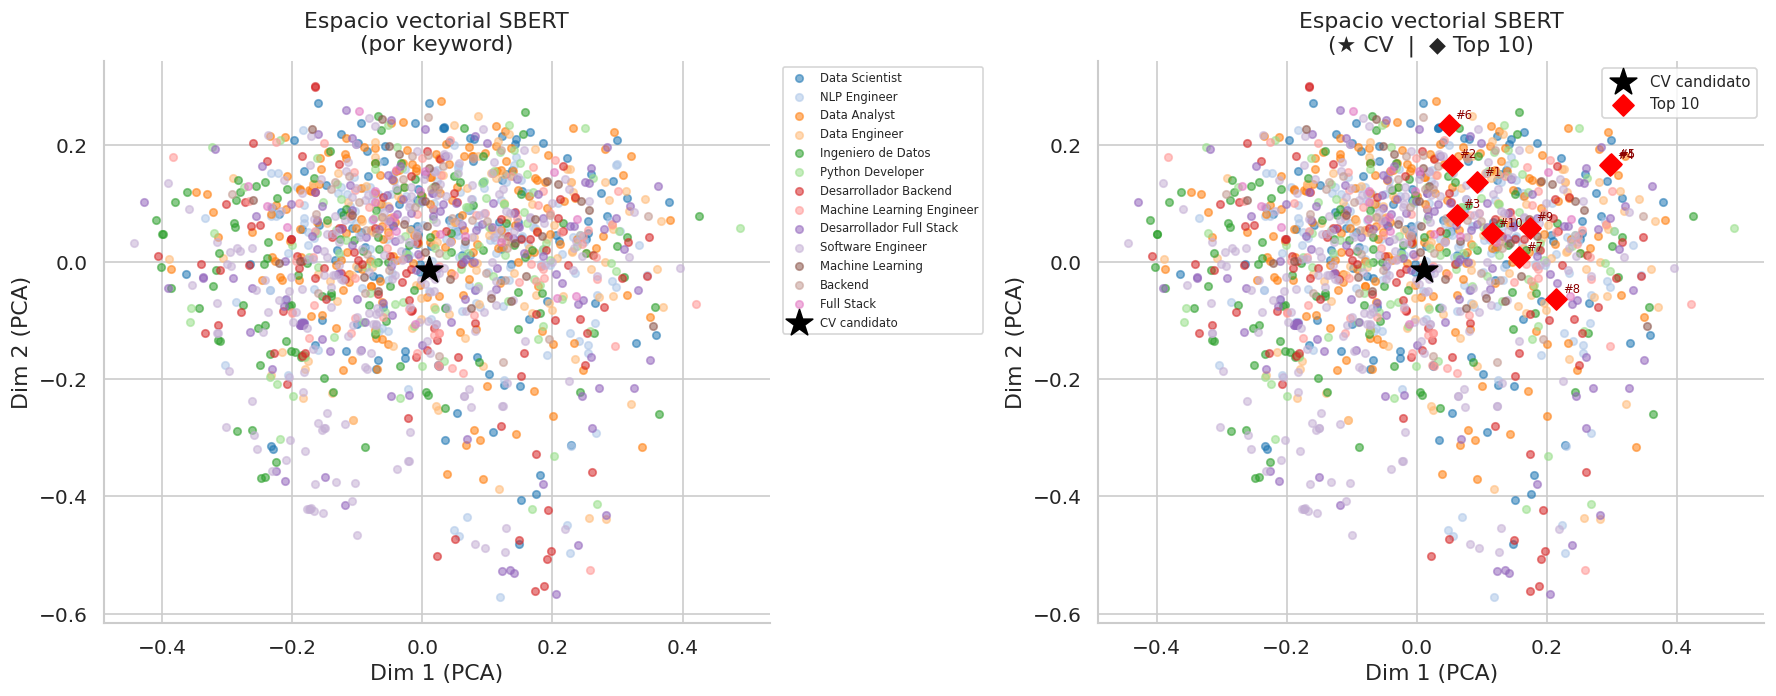

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

kws_u  = df['keyword'].unique()
kw_col = {kw: c for kw, c in zip(kws_u, sns.color_palette('tab20', len(kws_u)))}

for ax_idx, ax in enumerate(axes):
    for kw in kws_u:
        mask = df['keyword'] == kw
        ax.scatter(coords_of[mask, 0], coords_of[mask, 1],
                   color=kw_col[kw], s=20, alpha=0.55,
                   label=kw if ax_idx == 0 else '_nolegend_')

    ax.scatter(coord_cv_2d[0], coord_cv_2d[1], color='black',
               s=280, marker='*', zorder=10, label='CV candidato')

    if ax_idx == 1:   # segundo panel: resaltar Top 10
        top10_idx = df_ranking_emb.head(10).index - 1
        ax.scatter(coords_of[top10_idx, 0], coords_of[top10_idx, 1],
                   color='red', s=80, marker='D', zorder=9, label='Top 10')
        for rank, idx in enumerate(top10_idx, 1):
            ax.annotate(f'#{rank}',
                        (coords_of[idx, 0], coords_of[idx, 1]),
                        fontsize=7, color='darkred',
                        xytext=(4, 4), textcoords='offset points')

    titulo_ax = ('Espacio vectorial SBERT\n(por keyword)' if ax_idx == 0
                 else 'Espacio vectorial SBERT\n(★ CV  |  ◆ Top 10)')
    ax.set_title(titulo_ax)
    ax.set_xlabel(f'Dim 1 ({REDUCCION.upper()})')
    ax.set_ylabel(f'Dim 2 ({REDUCCION.upper()})')

axes[0].legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=7, frameon=True)
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig(_FIGS / 'fig_t5_04_espacio_vectorial.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Persistencia de artefactos

In [22]:
np.save(_EMBEDDINGS / 'embeddings_ofertas.npy', embeddings_ofertas)
np.save(_EMBEDDINGS / 'embedding_cv.npy', embedding_cv)
print(f'✅ embeddings_ofertas.npy  {embeddings_ofertas.shape}  {embeddings_ofertas.nbytes/1024/1024:.1f} MB')
print(f'✅ embedding_cv.npy        {embedding_cv.shape}')


✅ embeddings_ofertas.npy  (1402, 384)  2.1 MB
✅ embedding_cv.npy        (384,)


In [23]:
COLS_OUT = ['id_consolidado','fuente','titulo','empresa','keyword',
            'ubicacion','modalidad','url','similitud_embed']
cols_ok  = [c for c in COLS_OUT if c in df_ranking_emb.columns]
df_out   = df_ranking_emb[cols_ok].copy()
df_out.insert(0, 'rank_embed', range(1, len(df_out)+1))
df_out.to_csv(_RANKINGS / 'embeddings_ranking.csv', index=False, encoding='utf-8')
print(f'✅ embeddings_ranking.csv  {len(df_out):,} filas')


✅ embeddings_ranking.csv  1,402 filas


In [24]:
info = {
    'modelo': MODEL_NAME, 'dimensiones': EMBED_DIM,
    'max_chunk_chars': MAX_CHUNK_CHARS, 'chunk_overlap': CHUNK_OVERLAP,
    'batch_size': BATCH_SIZE, 'n_ofertas': len(df),
    'fecha_encoding': datetime.now().isoformat(),
    'col_texto_fuente': COL_TEXTO,
}
(_REPORTS / 'modelo_embeddings_info.json').write_text(
    json.dumps(info, ensure_ascii=False, indent=2), encoding='utf-8')
print('✅ modelo_embeddings_info.json')

print()
print('Archivos generados:')
rutas_salida = {
    'embeddings_ofertas.npy'     : _EMBEDDINGS / 'embeddings_ofertas.npy',
    'embedding_cv.npy'           : _EMBEDDINGS / 'embedding_cv.npy',
    'embeddings_ranking.csv'     : _RANKINGS   / 'embeddings_ranking.csv',
    'modelo_embeddings_info.json': _REPORTS    / 'modelo_embeddings_info.json',
}
for fn, p in rutas_salida.items():
    if p.exists():
        print(f'  📦 {fn:<42} {p.stat().st_size/1024:.0f} KB')


✅ modelo_embeddings_info.json

Archivos generados:
  📦 embeddings_ofertas.npy                     2103 KB
  📦 embedding_cv.npy                           2 KB
  📦 embeddings_ranking.csv                     304 KB
  📦 modelo_embeddings_info.json                0 KB


## 10. Resumen ejecutivo de T5

In [25]:
print('=' * 65)
print('  RESUMEN — T5: Vectorización con Sentence-BERT (Embeddings)')
print('=' * 65)
print(f"  Fecha : {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print()
print(f'  MODELO')
print(f'    {MODEL_NAME}')
print(f'    Dims {EMBED_DIM}  |  chunking {MAX_CHUNK_CHARS} chars  |  mean pooling')
print()
print(f'  CORPUS')
print(f'    Ofertas encodeadas : {len(df):,}  (ES + EN, multilingual)')
print()
sim = df['similitud_embed']
print(f'  RESULTADOS')
print(f'    Similitud promedio : {sim.mean():.4f}')
print(f'    Similitud máxima   : {sim.max():.4f}')
print(f'    Ofertas sim > 0.40 : {(sim>0.40).sum()}')
print(f'    Ofertas sim > 0.50 : {(sim>0.50).sum()}')
print()
print('  TOP 5 del ranking (Sentence-BERT):')
for i, row in df_ranking_emb.head(5).iterrows():
    print(f"    #{i:>2}. [{row['similitud_embed']:.4f}] {str(row['titulo'])[:42]}")
print()
if tfidf_disponible and tfidf_en_df:
    df_comp_r = df[['similitud_embed','similitud_tfidf']].dropna()
    corr_v = df_comp_r['similitud_tfidf'].corr(df_comp_r['similitud_embed'])
    print(f'  VS TF-IDF — Correlación Pearson: {corr_v:.4f}')
    print(f'  (ver Secciones 6.1-6.3 para análisis detallado)')
    print()
print('  ARTEFACTOS → T6')
print('    📦 embeddings_ofertas.npy')
print('    📦 embedding_cv.npy')
print('    📄 embeddings_ranking.csv')
print('    📄 modelo_embeddings_info.json')
print()
print('  PRÓXIMO PASO: T6 — Motor de Similitud y Cálculo de Ranks')
print('=' * 65)


  RESUMEN — T5: Vectorización con Sentence-BERT (Embeddings)
  Fecha : 2026-09-11 00:53

  MODELO
    paraphrase-multilingual-MiniLM-L12-v2
    Dims 384  |  chunking 800 chars  |  mean pooling

  CORPUS
    Ofertas encodeadas : 1,402  (ES + EN, multilingual)

  RESULTADOS
    Similitud promedio : 0.2761
    Similitud máxima   : 0.6103
    Ofertas sim > 0.40 : 86
    Ofertas sim > 0.50 : 12

  TOP 5 del ranking (Sentence-BERT):
    # 1. [0.6103] Desarrollador Full Stack Junior (Presencia
    # 2. [0.5727] Programador/a JAVA Senior – APIs
    # 3. [0.5677] Senior Bi & Data Analyst — Ai Dashboards O
    # 4. [0.5655] Desarrollador Full Stack
    # 5. [0.5527] Sr Software Engineer -Platform Services (M

  VS TF-IDF — Correlación Pearson: 0.0792
  (ver Secciones 6.1-6.3 para análisis detallado)

  ARTEFACTOS → T6
    📦 embeddings_ofertas.npy
    📦 embedding_cv.npy
    📄 embeddings_ranking.csv
    📄 modelo_embeddings_info.json

  PRÓXIMO PASO: T6 — Motor de Similitud y Cálculo de Ranks
